# Customer Churn Prediction and Retention Analysis Using Machine Learning

Dataset: IBM Telco Customer Churn dataset available on Kaggle


Problem Statement: Predict whether a customer is likely to churn and identify the factors that contribute most to churn.


Project Objective:

The objective of this project is to develop a machine learning system that predicts whether a telecommunications customer is likely to churn.

Using customer demographic information, subscribed services, account information, contract details and billing data, the project will identify customers at high risk of leaving the company.

Multiple machine learning models will be developed and compared using appropriate classification metrics. Model explainability techniques will also be used to identify the factors associated with customer churn and provide actionable insights that could support customer-retention strategies.

Dataset Information:

Customers who left within the last month – the column is called Churn

Services  – PhoneService, multiple lines, InternetService, online security, online backup, device protection, tech support, and streaming TV and movies

Account information – tenure, contract, payment method, paperless billing, monthly charges, and total charges

Demographics – gender, SeniorCitizen, partners and dependents




## Import Libraries

In [1]:
from idlelib.iomenu import errors
from unittest import result

import pandas as pd
import numpy as np
from pandas.core.interchange.from_dataframe import categorical_column_to_series

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("/Users/lata.bharati/Desktop/Projects/customer-churn-prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Data Understanding and Quality Check

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.shape)

(7043, 21)


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.describe(include='all')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [18]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [25]:
(df.astype(str).apply(lambda x: x.str.strip()) == "").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [26]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = 'coerce')


In [29]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [30]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["customerID"].nunique()

7043

In [37]:
df.nunique().sort_values()

Churn                  2
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PaperlessBilling       2
PhoneService           2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6530
customerID          7043
dtype: int64

Identify numerical and categorical columns

In [39]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int", "float"]).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)
print("Numerical Columns:")
print(numerical_columns)

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [42]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [43]:
(df["tenure"] == 0).sum()

np.int64(11)

In [45]:
quality_summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Unique_Values": df.nunique(),
    "Missing_Values": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})
quality_summary

,Data_Type,Unique_Values,Missing_Values,Missing %
customerID,str,7043,0,0.000000
gender,str,2,0,0.000000
SeniorCitizen,int64,2,0,0.000000
Partner,str,2,0,0.000000
Dependents,str,2,0,0.000000
tenure,int64,73,0,0.000000
PhoneService,str,2,0,0.000000
MultipleLines,str,3,0,0.000000
InternetService,str,3,0,0.000000
OnlineSecurity,str,3,0,0.000000


Fill null values in TotalCharges with 0

In [48]:
df[df["TotalCharges"].isnull()][["customerID","tenure","TotalCharges","Churn"]]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,NaN,No
753,3115-CZMZD,0,NaN,No
936,5709-LVOEQ,0,NaN,No
1082,4367-NUYAO,0,NaN,No
1340,1371-DWPAZ,0,NaN,No
3331,7644-OMVMY,0,NaN,No
3826,3213-VVOLG,0,NaN,No
4380,2520-SGTTA,0,NaN,No
5218,2923-ARZLG,0,NaN,No
6670,4075-WKNIU,0,NaN,No


In [49]:
df[df["TotalCharges"].isnull()]["tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [50]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

## Exploratory Data Analysis

Churn Distribution

In [51]:
import matplotlib.pyplot as plt

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


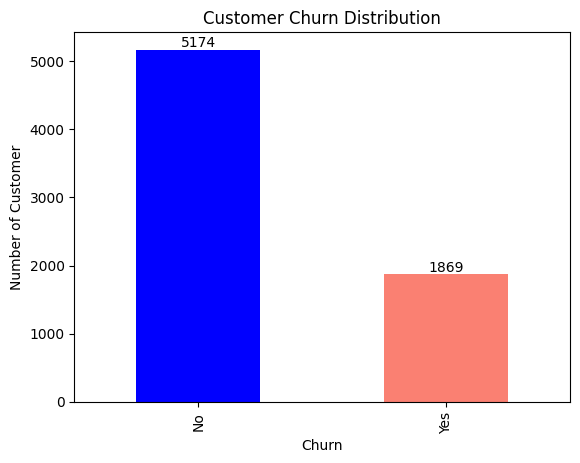

In [57]:
churn_counts = df["Churn"].value_counts()
print(df["Churn"].value_counts(normalize=True)*100)

ax = churn_counts.plot(kind="bar", color= ["blue", "salmon"])
for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customer")
plt.xlabel("Churn")
plt.xticks(rotation=90)
plt.show()

Churn vs Tenure

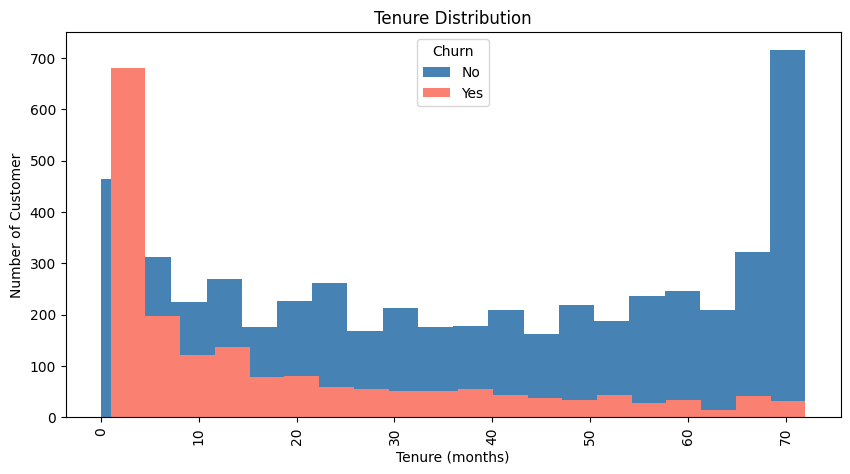

In [65]:
plt.figure(figsize=(10,5))
for churn_value, color in zip(["No", "Yes"],["steelblue","salmon"]):
    subset = df[df["Churn"] == churn_value]
    plt.hist(subset["tenure"], bins=20, color=color, label= churn_value)
plt.title("Tenure Distribution")
plt.ylabel("Number of Customer")
plt.xlabel("Tenure (months)")
plt.xticks(rotation=90)
plt.legend(title="Churn")
plt.xticks(rotation=90)
plt.show()

In [66]:
df.groupby("Churn")["tenure"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Churn,,,,
No,37.569965,24.113777,0,72
Yes,17.979133,19.531123,1,72


Churn vs MonthlyCharges

In [67]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Churn,,,,
No,61.265124,31.092648,18.25,118.75
Yes,74.441332,24.666053,18.85,118.35


<Figure size 1000x500 with 0 Axes>

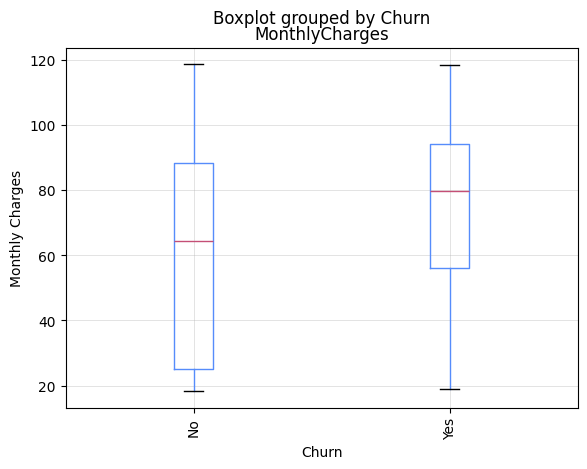

In [71]:
plt.figure(figsize=(10,5))
df.boxplot(column = "MonthlyCharges", by = "Churn")
plt.ylabel("Monthly Charges")
plt.xlabel("Churn")
plt.xticks(rotation=90)
plt.show()

Churn vs TotalCharges

In [72]:
df.groupby("Churn")["TotalCharges"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Churn,,,,
No,2549.911442,2329.954215,0.00,8672.45
Yes,1531.796094,1890.822994,18.85,8684.80


Churn vs Contract

In [74]:
contract_churn = pd.crosstab(df["Contract"],df["Churn"], normalize="index")*100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


<Figure size 1000x500 with 0 Axes>

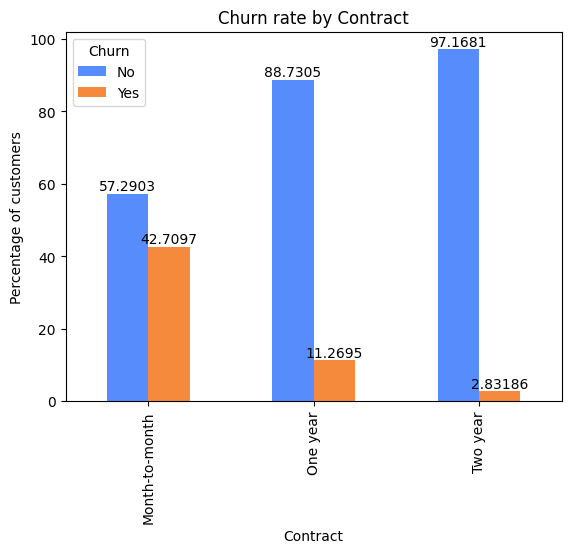

In [79]:
plt.figure(figsize=(10,5))
ax = contract_churn.plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn rate by Contract")
plt.ylabel("Percentage of customers")
plt.xlabel("Contract")
plt.xticks(rotation=90)
plt.show()


InternetService vs Churn

In [81]:
internet_churn = pd.crosstab(df["InternetService"],df["Churn"], normalize="index")*100
print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


<Figure size 1000x500 with 0 Axes>

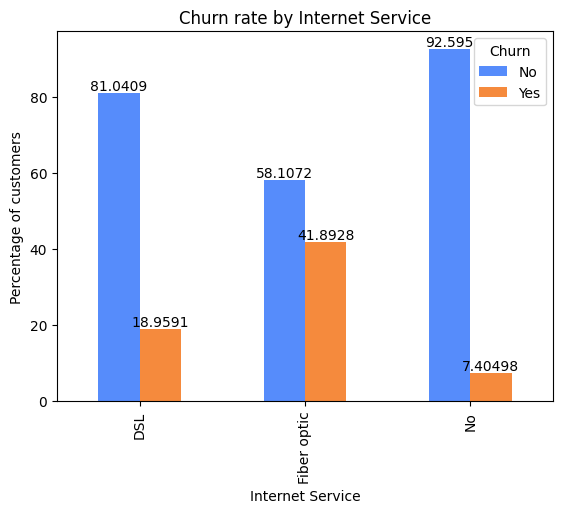

In [82]:
plt.figure(figsize=(10,5))
ax = internet_churn.plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn rate by Internet Service")
plt.ylabel("Percentage of customers")
plt.xlabel("Internet Service")
plt.xticks(rotation=90)
plt.show()

PaymentMethod vs Churn

In [83]:
payment_churn = pd.crosstab(df["PaymentMethod"],df["Churn"], normalize="index")*100
print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


<Figure size 1000x500 with 0 Axes>

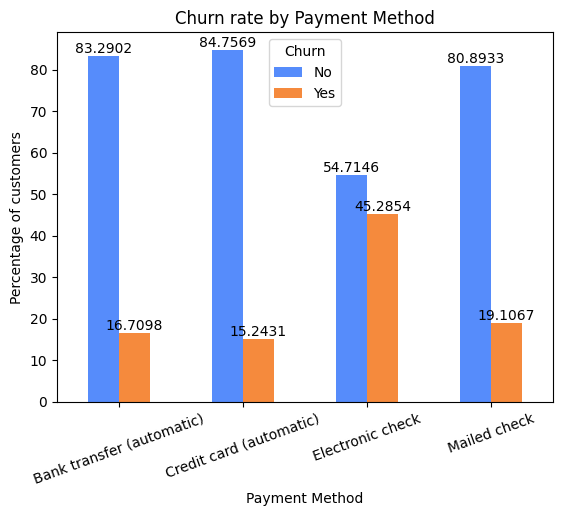

In [86]:
plt.figure(figsize=(10,5))
ax = payment_churn.plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn rate by Payment Method")
plt.ylabel("Percentage of customers")
plt.xlabel("Payment Method")
plt.xticks(rotation=20)
plt.show()

In [87]:
for col in ["TechSupport", "OnlineSecurity"]:
    result = pd.crosstab(df[col], df["Churn"], normalize="index")*100
    print(col)
    print(result)
    print()

TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341

OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194



Remaining Categorical variables

In [89]:
cols = ["SeniorCitizen", "Partner", "Dependents", "PaperlessBilling", "PhoneService", "MultipleLines"]

for col in cols:
    result = pd.crosstab(df[col], df["Churn"], normalize="index")*100
    print(col)
    print(result)
    print()

SeniorCitizen
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261

Partner
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

Dependents
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

PaperlessBilling
Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092

PhoneService
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896



Check correlation

In [90]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


## SUMMARY

The exploratory analysis identified several clear patters associated with churn.

* The overall churn rate was 26.5% which indicates moderate class imbalance.
* Customers who churned had much lower average tenure of around 18 months compared to 38 months for the customers who stayed.
* The churned customers had a higher monthly charges.
* Contract type showed one of the strongest relationships with churn. Customers on month-to-month contracts had a churn rate of about 42.7%, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.
* Customers using fiber optic internet and electronic check payments also showed substantially higher churn rates.
* Customers without TechSupport or OnlineSecurity had churn rates above 40%, while customers using these services had much lower churn rates.
* Higher churn was also observed among senior citizens, customers without partners or dependents, and customers using paperless billing. In contrast, PhoneService and MultipleLines showed relatively weak differences in churn rates.
* The correlation analysis showed a strong positive relationship between tenure and TotalCharges (0.83) and a moderate relationship between MonthlyCharges and TotalCharges (0.65).

Overall, the EDA suggests that tenure, contract type, monthly charges, internet service, payment method, technical support, and online security are likely to be important predictors of customer churn.
